<a href="https://colab.research.google.com/github/Muzzikon/Dynamic-Pricing-Algorithm-for-Retail/blob/main/WWML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import random

# The first 3 week

In [ ]:
def generate_apartment():
    location = random.randint(1, 10)
    rooms = random.randint(1, 6)
    distance = round(random.uniform(0.5, 25), 2)
    floor = random.randint(1, 25)
    S = round(rooms * random.uniform(15, 25) + random.uniform(10, 20), 1)
    #
    base_m2_price = 150000
    loc_coeff = 1.7 - (location / 10)
    dist_coeff = max(0.6, 1 - (distance / 50))
    final_m2_price = base_m2_price * loc_coeff * dist_coeff
    total_price = ((int((S * final_m2_price) * random.uniform(0.95, 1.05)) // 10000) * 10000)
    total_vis_price = str(total_price)[:-6] + '.' + str(total_price)[-6:-3] + '.' + str(total_price)[-4:-1]
    information = {"район": location, "площадь m^2": S, "кол-во комнат": rooms, "удаленность от центра (км)": distance, "этаж": floor, "цена": total_price}
    return information


In [ ]:
apartments = [generate_apartment() for i in range(10001)]
data_set = pd.DataFrame(apartments)
pd.set_option('display.expand_frame_repr', False) # Запретить перенос строк
pd.set_option('display.max_columns', None)       # Показывать все столбцы
print (data_set)

       район  площадь m^2  кол-во комнат  удаленность от центра (км)  этаж      цена
0         10         98.9              4                       20.68     6   6010000
1          7         65.8              2                       22.05    22   5790000
2          9        118.3              6                       19.93     7   8450000
3          8         29.7              1                        2.69    10   3870000
4          4        160.1              6                       22.88    19  18610000
...      ...          ...            ...                         ...   ...       ...
9996      10         49.1              2                       21.61     6   3110000
9997       3         73.4              3                       18.71     4  10060000
9998       5         70.8              3                       24.98     5   7580000
9999       8         36.7              1                        2.91    12   4700000
10000      2         78.6              3                        7

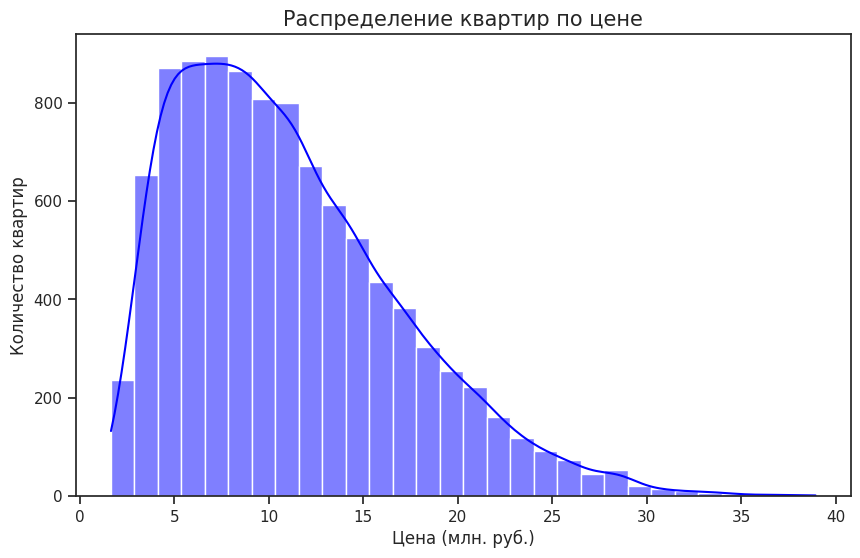

In [ ]:
#Гистограмма
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")
plt.figure(figsize=(10,6))
prices_in_millions = data_set["цена"] / 1_000_000
sns.histplot(prices_in_millions, bins=30, kde=True, color='blue')
plt.title("Распределение квартир по цене",fontsize=15)
plt.xlabel("Цена (млн. руб.)", fontsize=12)
plt.ylabel("Количество квартир", fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'район'),
  Text(0, 1.5, 'площадь m^2'),
  Text(0, 2.5, 'кол-во комнат'),
  Text(0, 3.5, 'удаленность от центра (км)'),
  Text(0, 4.5, 'этаж'),
  Text(0, 5.5, 'цена')])

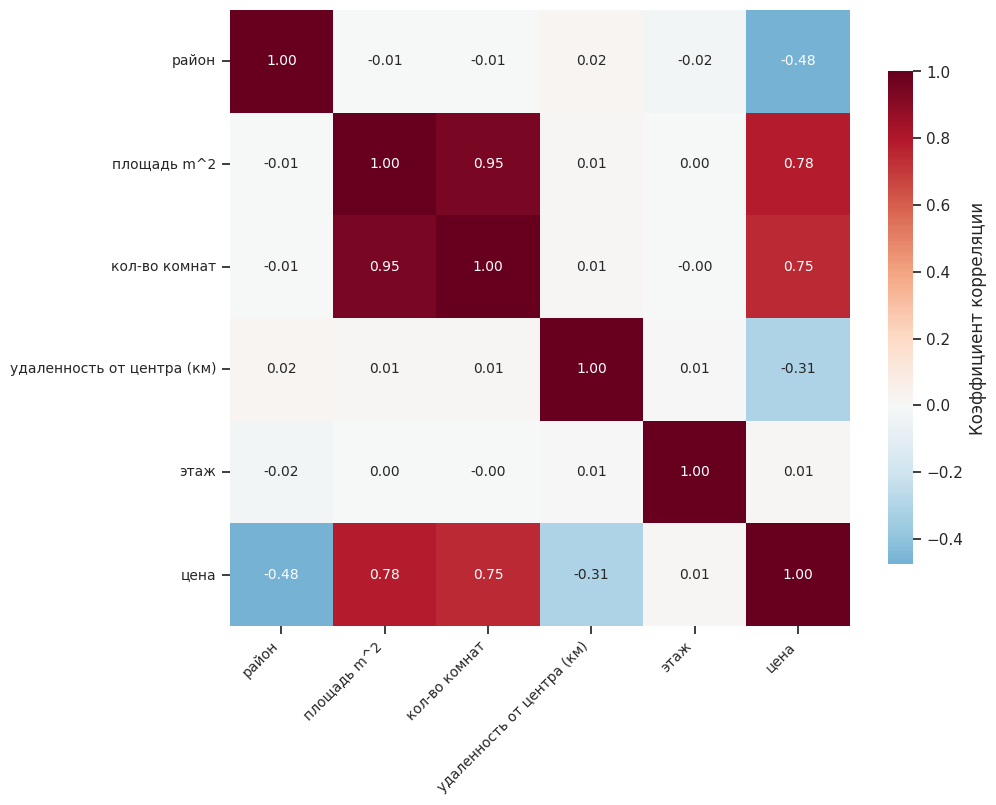

In [ ]:
# Матрица корреляции
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

correlation_matrix = data_set.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='RdBu_r',
            center=0,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            fmt='.2f',
            annot_kws={'size': 10})

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

